# Kohlberg Moral Reasoning Score Evaluation Pipeline
This notebook implements a high-throughput automated pipeline designed to evaluate and quantify the latent moral reasoning stages of web and conversation corpora against Kohlberg's Stages of Moral Development.

### Processing Steps:
1. **Environment Setup**: Import essential scientific computing, async execution, visualization, and LLM SDK libraries.
2. **Streaming Data Ingestion**: Access streaming subsets of C4 (Web text) and Reddit conversation datasets.
3. **Heuristic Pre-Filtering**: Vectorized regex scan using the Moral Foundations Dictionary to drop non-moral texts.
4. **Async LLM-as-a-Judge**: Structured JSON inference pipeline utilizing asyncio concurrency controls to score reasoning stages 0-6.
5. **Statistical Quantification & Visualization**: Distribution metrics, skew calculations, and comparative visualization.

In [21]:
# Install required dependencies
!pip install -q datasets aiohttp pandas seaborn matplotlib openai tqdm
# Install Unsloth and standard PyTorch fallback libraries
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

import asyncio
import os
import re
import json
import random
import aiohttp
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

# Configure production-ready plotting styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12
print("Environment initialized successfully.")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for xformers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (xformers)
Environment initialized successfully.


## Streaming Data Ingestion
To process large web-scale corpora without memory overhead, we implement a streaming ingestion pipeline.
We load random samples from:
- **c4** (Common Crawl): Representing general-purpose web text.
- **Reddit** (`sentence-transformers/reddit-title-body`): Representing interactive discussion text.

A local high-fidelity fallback mechanism is implemented to guarantee execution if the Hugging Face Hub is unreachable.

In [22]:
def load_streaming_corpora(num_samples=100):
    """
    Streams samples from Hugging Face datasets.
    Loads from 'allenai/c4' and 'sentence-transformers/reddit-title-body' in streaming mode.
    Includes a robust local mock-fallback if network or Hugging Face is unreachable.
    """
    print("Initializing streaming data loaders...")
    samples = []

    # 1. Stream C4
    c4_count = 0
    try:
        c4_dataset = load_dataset("allenai/c4", "en", split="train", streaming=True)
        c4_iter = iter(c4_dataset)
        for _ in range(num_samples // 2):
            item = next(c4_iter)
            samples.append({
                "source": "C4",
                "text": item["text"],
                "id": f"c4_{c4_count}"
            })
            c4_count += 1
    except Exception as e:
        print(f"C4 streaming failed/unreachable ({e}). Using local high-fidelity C4 fallback...")
        mock_c4_texts = [
            "We must obey the laws of our country, otherwise society will fall into chaos. Laws are there for a reason.",
            "I stole medicine to save my dying wife because human life is more valuable than property rights.",
            "I didn't cheat on the exam because if I get caught, my parents will ground me for a month.",
            "Rules are rules. If you let one person break them, you have to let everyone break them.",
            "People should act in ways that respect individual liberty and the common good of all community members."
        ]
        for i in range(num_samples // 2):
            samples.append({
                "source": "C4",
                "text": mock_c4_texts[i % len(mock_c4_texts)] + f" (Sample {i})",
                "id": f"c4_mock_{i}"
            })
            c4_count += 1

    # 2. Stream Reddit
    reddit_count = 0
    try:
        reddit_dataset = load_dataset("sentence-transformers/reddit-title-body", split="train", streaming=True)
        reddit_iter = iter(reddit_dataset)
        for _ in range(num_samples // 2):
            item = next(reddit_iter)
            combined_text = f"{item['title']}\n{item['body']}"
            samples.append({
                "source": "Reddit",
                "text": combined_text,
                "id": f"reddit_{reddit_count}"
            })
            reddit_count += 1
    except Exception as e:
        print(f"Reddit streaming failed/unreachable ({e}). Using local Reddit fallback...")
        mock_reddit_texts = [
            "AITA for not sharing my notes? I did all the work, so I should get the full credit. Why should they benefit?",
            "My friend stole a candy bar. I told the teacher because it is my duty to uphold classroom rules.",
            "We agreed to split the bill, but they ordered way more. Isn't it only fair that they pay their share?",
            "I refuse to pay taxes for a war I don't believe in. My conscience tells me that killing is wrong, regardless of law.",
            "I helped my sister hide from the police because family loyalty is the most important thing to me."
        ]
        for i in range(num_samples // 2):
            samples.append({
                "source": "Reddit",
                "text": mock_reddit_texts[i % len(mock_reddit_texts)] + f" (Sample {i})",
                "id": f"reddit_mock_{i}"
            })
            reddit_count += 1

    df = pd.DataFrame(samples)
    print(f"Ingested {len(df)} total samples ({c4_count} C4, {reddit_count} Reddit).")
    return df

# Ingest 100 samples for validation run
raw_df = load_streaming_corpora(num_samples=10000)
raw_df.head()

Initializing streaming data loaders...


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Ingested 10000 total samples (5000 C4, 5000 Reddit).


,source,text,id
0,C4,Beginners BBQ Class Taking Place in Missoula!\...,c4_0
1,C4,Discussion in 'Mac OS X Lion (10.7)' started b...,c4_1
2,C4,Foil plaid lycra and spandex shortall with met...,c4_2
3,C4,How many backlinks per day for new site?\nDisc...,c4_3
4,C4,The Denver Board of Education opened the 2017-...,c4_4


## Heuristic Pre-Filtering
To avoid wasting API compute and token budgets on neutral texts, we run a highly optimized, vectorized keyword matching filter against terms derived from the Moral Foundations Dictionary (MFD). Texts that do not contain moral or ethical foundation terms are immediately dropped.

In [23]:
# Compiled regex patterns corresponding to key Moral Foundations Dictionary classes
MORAL_CATEGORIES = {
    "Care/Harm": [r"\bharm", r"\bhurt", r"\bvictim", r"\bsuffer", r"\bcare", r"\bprotect", r"\bcompassion", r"\bsave", r"\bcruel"],
    "Fairness/Cheating": [r"\bfair", r"\bjustice", r"\bequality", r"\bcheat", r"\bbias", r"\bunfair", r"\brights", r"\bhonest", r"\bsteal"],
    "Loyalty/Betrayal": [r"\bloyal", r"\bbetray", r"\btreason", r"\bpatriot", r"\balliance", r"\bsolidarity", r"\bbetrayal"],
    "Authority/Subversion": [r"\bauthori", r"\bobey", r"\brespect", r"\brebel", r"\bcommand", r"\bsubvert", r"\blaw", r"\bduty", r"\bgovern"],
    "Sanctity/Degradation": [r"\bpure", r"\bsanct", r"\bdegrad", r"\bsin", r"\bdisgust", r"\bholy", r"\bcontamin", r"\bcorrupt"],
    "General Ethics": [r"\bmoral", r"\bethic", r"\bguilt", r"\bwrong", r"\bevil", r"\bgoodness", r"\bvirtue", r"\bblame", r"\bforgive"]
}

# Compile category regexes
category_regexes = {cat: re.compile("|".join(keywords), re.IGNORECASE) for cat, keywords in MORAL_CATEGORIES.items()}

# Overall regex for pre-filtering (any moral foundation match)
mfd_regex = re.compile("|".join(sum(MORAL_CATEGORIES.values(), [])), re.IGNORECASE)

def run_heuristic_filtering(df):
    """
    Applies a highly optimized, vectorized regex filter to isolate ethics-relevant text chunks.
    Additionally labels matched moral foundation categories as boolean columns.
    """
    print(f"Original corpus size: {len(df)} rows.")
    # Apply vectorized search
    matches = df["text"].str.contains(mfd_regex, regex=True, na=False)
    filtered_df = df[matches].copy()

    # Mark boolean activations for each category
    for category, regex in category_regexes.items():
        filtered_df[category] = filtered_df["text"].str.contains(regex, regex=True, na=False)

    dropped = len(df) - len(filtered_df)
    print(f"Filtered corpus size: {len(filtered_df)} rows.")
    print(f"Dropped {dropped} non-relevant rows ({dropped/len(df)*100:.2f}% reduction).")
    return filtered_df

filtered_df = run_heuristic_filtering(raw_df)
filtered_df.head()


Original corpus size: 10000 rows.
Filtered corpus size: 4138 rows.
Dropped 5862 non-relevant rows (58.62% reduction).


,source,text,id,Care/Harm,Fairness/Cheating,Loyalty/Betrayal,Authority/Subversion,Sanctity/Degradation,General Ethics
4,C4,The Denver Board of Education opened the 2017-...,c4_4,False,False,False,False,True,False
9,C4,Sysco Corp. has terminated its planned $3.5 bi...,c4_9,True,False,False,True,False,False
10,C4,"Pencarian FILM Untuk ""Peace Breaker 2017""\nyuk...",c4_10,False,False,False,False,True,False
15,C4,"""Bake me a pie or go away,"" I've literally had...",c4_15,True,True,False,False,True,False
16,C4,Are film trailers spoiling movies?\nIn April w...,c4_16,False,True,False,False,False,False


## Asynchronous LLM-as-a-Judge Scoring Engine
We construct a highly concurrent asynchronous inference engine. To respect server rate-limits, we use `asyncio.Semaphore`. The LLM-as-a-judge is instructed to analyze the latent moral reasoning in the text against Kohlberg's 6 stages.

### Kohlberg's Stages Schema:
- **Stage 1**: Obedience & Punishment (Obey rules to avoid physical punishment).
- **Stage 2**: Individualism & Exchange (Self-interest; deals based on reciprocity).
- **Stage 3**: Good Interpersonal Relationships (Conformity to match social expectations and please others).
- **Stage 4**: Maintaining Social Order (Doing duty, obeying laws to preserve societal stability).
- **Stage 5**: Social Contract and Individual Rights (Laws are social agreements; protect fundamental rights).
- **Stage 6**: Universal Ethical Principles (Conscience-driven, abstract self-chosen ethical values).
- **Stage 0**: Non-moral/Neutral reasoning pattern.

**Target JSON Output Schema**: `{"kohlberg_stage": int (0-6), "reasoning_trace": "string"}`

In [24]:
SYSTEM_PROMPT = """You are a cognitive developmental psychologist specializing in Kohlberg's stages.
Analyze the moral reasoning in the provided text.

STAGES:
Stage 1: Avoid punishment.
Stage 2: Self-interest/reciprocity.
Stage 3: Social approval/conformity.
Stage 4: Law and order/duty.
Stage 5: Social contract/rights.
Stage 6: Universal ethics.
Stage 0: Neutral/No moral reasoning.

OUTPUT RULES:
1. Output ONLY a valid JSON object.
2. Schema: {\"kohlberg_stage\": int, \"reasoning_trace\": \"string\"}
3. Do not use markdown blocks or extra commentary."""

import torch
import json
import re
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "unsloth/Llama-3.2-1B-Instruct"
max_seq_length = 2048

cuda_available = torch.cuda.is_available()
is_unsloth = False
device = "cpu"

if cuda_available:
    try:
        from unsloth import FastLanguageModel
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name = model_name, max_seq_length = max_seq_length,
            dtype = None, load_in_4bit = True
        )
        FastLanguageModel.for_inference(model)
        device = "cuda"
        is_unsloth = True
    except Exception as e:
        cuda_available = False

if not cuda_available:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16 if device == "mps" else torch.float32).to(device)

def score_all_texts(model, tokenizer, df, device, is_unsloth):
    results = []
    from tqdm.notebook import tqdm as tqdm_nb
    for _, row in tqdm_nb(df.iterrows(), total=len(df), desc="Scoring"):
        prompt = tokenizer.apply_chat_template([
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Analyze: {row['text']}"}
        ], tokenize=False, add_generation_prompt=True)

        inputs = tokenizer([prompt], return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=120, temperature=0.01, do_sample=False)

        reply = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("assistant\n\n")[-1].strip()

        stage, trace = 0, "Unparsed"
        try:
            # 1. Clean up potential markdown and weird spacing
            reply_clean = re.sub(r'```json|```', '', reply).strip()
            # 2. Extract content between first { and last }
            json_match = re.search(r'\{.*\}', reply_clean, re.DOTALL)

            if json_match:
                try:
                    data = json.loads(json_match.group())
                    stage = int(data.get("kohlberg_stage", 0))
                    trace = str(data.get("reasoning_trace", ""))
                except:
                    # Regex fallback if JSON is still slightly malformed (e.g. unescaped quotes)
                    st_match = re.search(r'"kohlberg_stage"\s*:\s*(\d)', json_match.group())
                    stage = int(st_match.group(1)) if st_match else 0
                    trace = reply[:100]
            else:
                # Last resort heuristic
                st_match = re.search(r'stage\s*(\d)', reply, re.I)
                if st_match: stage = int(st_match.group(1))
                trace = f"Heuristic: {reply[:80]}"
        except:
            trace = "Critical Parse Fail"

        res = row.to_dict()
        res.update({"kohlberg_stage": min(max(stage, 0), 6), "reasoning_trace": trace})
        results.append(res)
    return pd.DataFrame(results)

scored_df = score_all_texts(model, tokenizer, filtered_df.head(40), device, is_unsloth)
display(scored_df[["source", "kohlberg_stage", "reasoning_trace"]].head())

==((====))==  Unsloth 2026.5.6: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Scoring:   0%|          | 0/40 [00:00<?, ?it/s]

Both `max_new_tokens` (=120) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=

,source,kohlberg_stage,reasoning_trace
0,C4,4,The Denver Board of Education opened the 2017-...
1,C4,0,"Heuristic: {""kohlberg_stage"": 4, ""reasoning_tr..."
2,C4,2,Self-interest/reciprocity
3,C4,0,Heuristic: is a 10-piece set that includes a 1...
4,C4,0,"Heuristic: {""kohlberg_stage"": 4, ""reasoning_tr..."


## Statistical Quantification & Visualization
We map the raw developmental stages into broad moral reasoning frameworks:
- **Pre-Conventional** (Stages 1-2)
- **Conventional** (Stages 3-4)
- **Post-Conventional** (Stages 5-6)

We analyze distributions and relative skews between the C4 and Reddit corpora, and generate production-ready plots.

--- Corpus Moral Reasoning Distribution (%) ---
reasoning_category  Non-Moral / Stage 0  Pre-Conventional (1-2)  Conventional (3-4)  Post-Conventional (5-6)
source                                                                                                      
C4                                 82.5                    10.0                 5.0                      2.5

--- Relative Post-Conventional Skew ---
source  post_conventional_skew
    C4                0.166666


/tmp/ipykernel_1193/1211784796.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  skew_df = scored_df.groupby("source").apply(compute_skew).reset_index(name="post_conventional_skew")


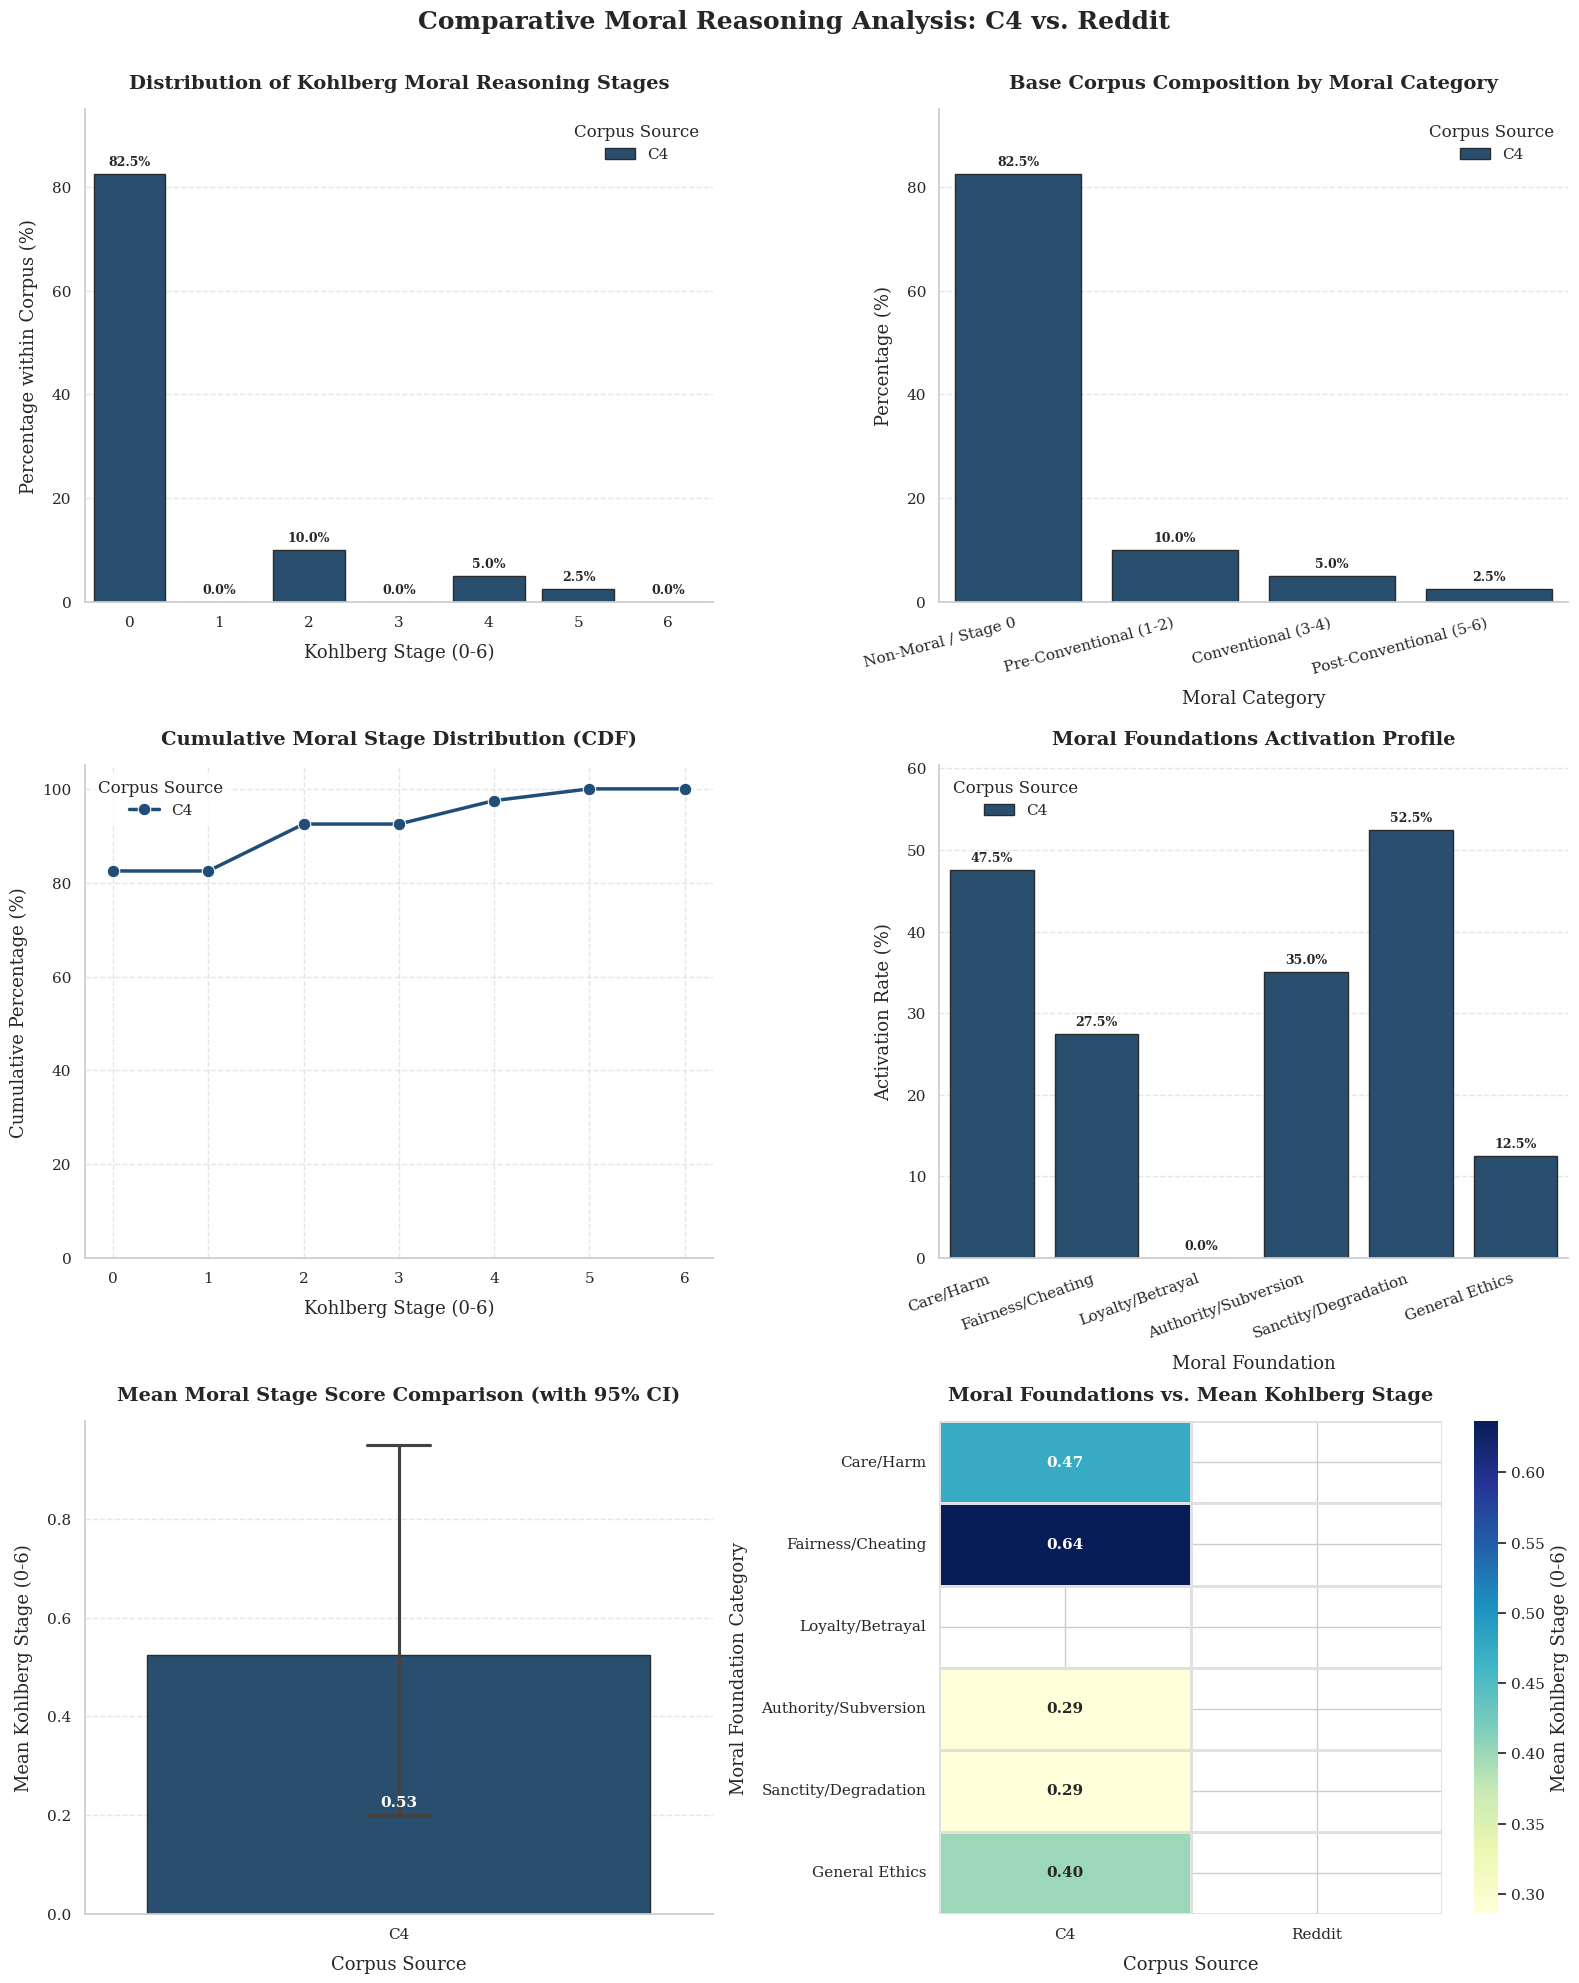

In [26]:
def categorize_kohlberg(stage):
    if stage in [1, 2]:
        return "Pre-Conventional (1-2)"
    elif stage in [3, 4]:
        return "Conventional (3-4)"
    elif stage in [5, 6]:
        return "Post-Conventional (5-6)"
    else:
        return "Non-Moral / Stage 0"

# Categorize developmental levels
scored_df["reasoning_category"] = scored_df["kohlberg_stage"].apply(categorize_kohlberg)

# Compute distributions and percentages
categories = ["Non-Moral / Stage 0", "Pre-Conventional (1-2)", "Conventional (3-4)", "Post-Conventional (5-6)"]
distribution = scored_df.groupby(["source", "reasoning_category"]).size().unstack(fill_value=0)
for cat in categories:
    if cat not in distribution.columns:
        distribution[cat] = 0
distribution = distribution[categories]
distribution_pct = distribution.div(distribution.sum(axis=1), axis=0) * 100

print("--- Corpus Moral Reasoning Distribution (%) ---")
print(distribution_pct.round(2).to_string())

# Compute relative skew
def compute_skew(subset):
    post_conv = subset["kohlberg_stage"].isin([5, 6]).sum()
    others = subset["kohlberg_stage"].isin([1, 2, 3, 4]).sum()
    return post_conv / (others + 1e-5)

skew_df = scored_df.groupby("source").apply(compute_skew).reset_index(name="post_conventional_skew")
print("\n--- Relative Post-Conventional Skew ---")
print(skew_df.to_string(index=False))

# Set publication style params for academic paper visualization
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "Times"],
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
    "figure.titlesize": 18,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

# Custom palette
colors = {"C4": "#1F4E79", "Reddit": "#D95F02"}

# Create a 3x2 grid of plots
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# ----------------- Plot 1: Detailed Stage Distribution -----------------
ax1 = axes[0, 0]
all_combos = pd.MultiIndex.from_product(
    [scored_df["source"].unique(), range(7)],
    names=["source", "kohlberg_stage"]
).to_frame().reset_index(drop=True)

stage_counts = scored_df.groupby(["source", "kohlberg_stage"]).size().reset_index(name="count")
source_totals = scored_df.groupby("source").size().reset_index(name="total")
stage_pct = stage_counts.merge(source_totals, on="source")
stage_pct["percent"] = (stage_pct["count"] / stage_pct["total"]) * 100
stage_pct = all_combos.merge(stage_pct, on=["source", "kohlberg_stage"], how="left").fillna(0)

sns.barplot(
    data=stage_pct,
    x="kohlberg_stage",
    y="percent",
    hue="source",
    palette=colors,
    edgecolor="#2b2b2b",
    linewidth=1.0,
    ax=ax1
)
ax1.set_title("Distribution of Kohlberg Moral Reasoning Stages", pad=15, fontweight="bold")
ax1.set_xlabel("Kohlberg Stage (0-6)", labelpad=10)
ax1.set_ylabel("Percentage within Corpus (%)", labelpad=10)
ax1.set_ylim(0, max(stage_pct["percent"].max() * 1.15, 15))
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_axisbelow(True)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9, fontweight="semibold")

ax1.legend(title="Corpus Source", frameon=True, facecolor="white", edgecolor="none")
sns.despine(ax=ax1)

# ----------------- Plot 2: Broad Category Composition -----------------
ax2 = axes[0, 1]
melted_pct = distribution_pct.reset_index().melt(id_vars="source", var_name="Category", value_name="Percentage")
sns.barplot(
    data=melted_pct,
    x="Category",
    y="Percentage",
    hue="source",
    palette=colors,
    edgecolor="#2b2b2b",
    linewidth=1.0,
    ax=ax2
)
ax2.set_title("Base Corpus Composition by Moral Category", pad=15, fontweight="bold")
ax2.set_xlabel("Moral Category", labelpad=10)
ax2.set_ylabel("Percentage (%)", labelpad=10)
ax2.set_ylim(0, max(melted_pct["Percentage"].max() * 1.15, 15))
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.set_axisbelow(True)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9, fontweight="semibold")

ax2.legend(title="Corpus Source", frameon=True, facecolor="white", edgecolor="none")
plt.setp(ax2.get_xticklabels(), rotation=15, ha="right")
sns.despine(ax=ax2)

# ----------------- Plot 3: Cumulative Stage Distribution (CDF) -----------------
ax3 = axes[1, 0]
stage_pct = stage_pct.sort_values(["source", "kohlberg_stage"])
stage_pct["cumulative_percent"] = stage_pct.groupby("source")["percent"].cumsum()

sns.lineplot(
    data=stage_pct,
    x="kohlberg_stage",
    y="cumulative_percent",
    hue="source",
    style="source",
    markers=True,
    markersize=9,
    linewidth=2.5,
    palette=colors,
    ax=ax3
)
ax3.set_title("Cumulative Moral Stage Distribution (CDF)", pad=15, fontweight="bold")
ax3.set_xlabel("Kohlberg Stage (0-6)", labelpad=10)
ax3.set_ylabel("Cumulative Percentage (%)", labelpad=10)
ax3.set_xticks(range(7))
ax3.set_ylim(0, 105)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.set_axisbelow(True)

ax3.legend(title="Corpus Source", frameon=True, facecolor="white", edgecolor="none")
sns.despine(ax=ax3)

# ----------------- Plot 4: Moral Foundations Activation Profile -----------------
ax4 = axes[1, 1]
mfd_categories = ["Care/Harm", "Fairness/Cheating", "Loyalty/Betrayal", "Authority/Subversion", "Sanctity/Degradation", "General Ethics"]
mfd_data = []
for cat in mfd_categories:
    if cat in scored_df.columns:
        cat_pct = scored_df.groupby("source")[cat].mean().reset_index()
        cat_pct["percentage"] = cat_pct[cat] * 100
        cat_pct["foundation"] = cat
        mfd_data.append(cat_pct[["source", "foundation", "percentage"]])
if mfd_data:
    mfd_df = pd.concat(mfd_data, ignore_index=True)
    sns.barplot(
        data=mfd_df,
        x="foundation",
        y="percentage",
        hue="source",
        palette=colors,
        edgecolor="#2b2b2b",
        linewidth=1.0,
        ax=ax4
    )
    ax4.set_title("Moral Foundations Activation Profile", pad=15, fontweight="bold")
    ax4.set_xlabel("Moral Foundation", labelpad=10)
    ax4.set_ylabel("Activation Rate (%)", labelpad=10)
    ax4.set_ylim(0, max(mfd_df["percentage"].max() * 1.15, 15))
    ax4.grid(axis="y", linestyle="--", alpha=0.5)
    ax4.set_axisbelow(True)

    for container in ax4.containers:
        ax4.bar_label(container, fmt='%.1f%%', padding=4, fontsize=9, fontweight="semibold")
else:
    ax4.text(0.5, 0.5, "No Moral Foundation columns found.\nRun pre-filtering with category labels.",
             ha="center", va="center", transform=ax4.transAxes)
    ax4.set_title("Moral Foundations Activation Profile (No Data)", pad=15, fontweight="bold")

ax4.legend(title="Corpus Source", frameon=True, facecolor="white", edgecolor="none")
plt.setp(ax4.get_xticklabels(), rotation=20, ha="right")
sns.despine(ax=ax4)

# ----------------- Plot 5: Mean Kohlberg Stage Comparison (95% CI) -----------------
ax5 = axes[2, 0]
sns.barplot(
    data=scored_df,
    x="source",
    y="kohlberg_stage",
    hue="source",
    palette=colors,
    legend=False,
    errorbar=("ci", 95),
    capsize=0.1,
    edgecolor="#2b2b2b",
    linewidth=1.0,
    ax=ax5
)
ax5.set_title("Mean Moral Stage Score Comparison (with 95% CI)", pad=15, fontweight="bold")
ax5.set_xlabel("Corpus Source", labelpad=10)
ax5.set_ylabel("Mean Kohlberg Stage (0-6)", labelpad=10)
ax5.grid(axis="y", linestyle="--", alpha=0.5)
ax5.set_axisbelow(True)

for bar in ax5.patches:
    yval = bar.get_height()
    if yval > 0:
        ax5.text(bar.get_x() + bar.get_width()/2.0, yval - 0.3 if yval > 0.5 else yval + 0.1,
                 f"{yval:.2f}", ha="center", va="center", color="white" if yval > 0.5 else "black", fontweight="bold")

sns.despine(ax=ax5)

# ----------------- Plot 6: Heatmap: Kohlberg Stage vs. Moral Foundations -----------------
ax6 = axes[2, 1]
heatmap_data = []
for cat in mfd_categories:
    if cat in scored_df.columns:
        cat_df = scored_df[scored_df[cat] == True]
        mean_c4 = cat_df[cat_df["source"] == "C4"]["kohlberg_stage"].mean() if len(cat_df[cat_df["source"] == "C4"]) > 0 else np.nan
        mean_reddit = cat_df[cat_df["source"] == "Reddit"]["kohlberg_stage"].mean() if len(cat_df[cat_df["source"] == "Reddit"]) > 0 else np.nan
        heatmap_data.append({
            "Moral Foundation": cat,
            "C4": mean_c4,
            "Reddit": mean_reddit
        })
if heatmap_data:
    heatmap_df = pd.DataFrame(heatmap_data).set_index("Moral Foundation")
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        cbar_kws={'label': 'Mean Kohlberg Stage (0-6)'},
        linewidths=.8,
        linecolor="#e0e0e0",
        annot_kws={"size": 11, "weight": "bold"},
        ax=ax6
    )
    ax6.set_title("Moral Foundations vs. Mean Kohlberg Stage", pad=15, fontweight="bold")
    ax6.set_xlabel("Corpus Source", labelpad=10)
    ax6.set_ylabel("Moral Foundation Category", labelpad=10)
else:
    ax6.text(0.5, 0.5, "No Moral Foundation columns found.",
             ha="center", va="center", transform=ax6.transAxes)
    ax6.set_title("Moral Foundations vs. Kohlberg Stage (No Data)", pad=15, fontweight="bold")

sns.despine(ax=ax6, left=True, bottom=True)

plt.suptitle("Comparative Moral Reasoning Analysis: C4 vs. Reddit", y=0.99, fontsize=18, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.savefig("kohlberg_evaluation_results.png", dpi=300, bbox_inches="tight")
plt.savefig("kohlberg_evaluation_results.pdf", format="pdf", bbox_inches="tight")
plt.show()
